In [1]:
# Install required packages
!pip install kagglehub opencv-python-headless matplotlib seaborn scikit-learn tensorflow -q

import kagglehub

# Download the LeapGestRecog dataset
path = kagglehub.dataset_download("gti-upm/leapgestrecog")
print("✅ Path to dataset files:", path)

Resuming download from 131072000 bytes (2155013038 bytes left)...
Resuming download to C:\Users\shahf\.cache\kagglehub\datasets\gti-upm\leapgestrecog\1.archive (131072000/2286085038) bytes left.


100%|█████████████████████████████████████████████████████████████████████████████| 2.13G/2.13G [17:22<00:00, 2.07MB/s]

Extracting files...


✅ Path to dataset files: C:\Users\shahf\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import random

# ── Locate image root ──────────────────────────────────────────────────────────
def find_image_root(base_path):
    """Walk down until we find a folder that contains sub-folders with images."""
    for root, dirs, files in os.walk(base_path):
        imgs = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if imgs and os.path.dirname(root) != base_path:
            return os.path.dirname(root)
    return base_path

DATA_DIR = find_image_root(path)
print("📁 Image root:", DATA_DIR)

# ── Class discovery ────────────────────────────────────────────────────────────
GESTURE_CLASSES = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
NUM_CLASSES = len(GESTURE_CLASSES)
print(f"\n🤚 Found {NUM_CLASSES} gesture classes:")
for i, g in enumerate(GESTURE_CLASSES):
    count = len(os.listdir(os.path.join(DATA_DIR, g)))
    print(f"   [{i:02d}] {g:30s}  —  {count} images")

📁 Image root: C:\Users\shahf\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1\leapGestRecog\00

🤚 Found 10 gesture classes:
   [00] 01_palm                         —  200 images
   [01] 02_l                            —  200 images
   [02] 03_fist                         —  200 images
   [03] 04_fist_moved                   —  200 images
   [04] 05_thumb                        —  200 images
   [05] 06_index                        —  200 images
   [06] 07_ok                           —  200 images
   [07] 08_palm_moved                   —  200 images
   [08] 09_c                            —  200 images
   [09] 10_down                         —  200 images


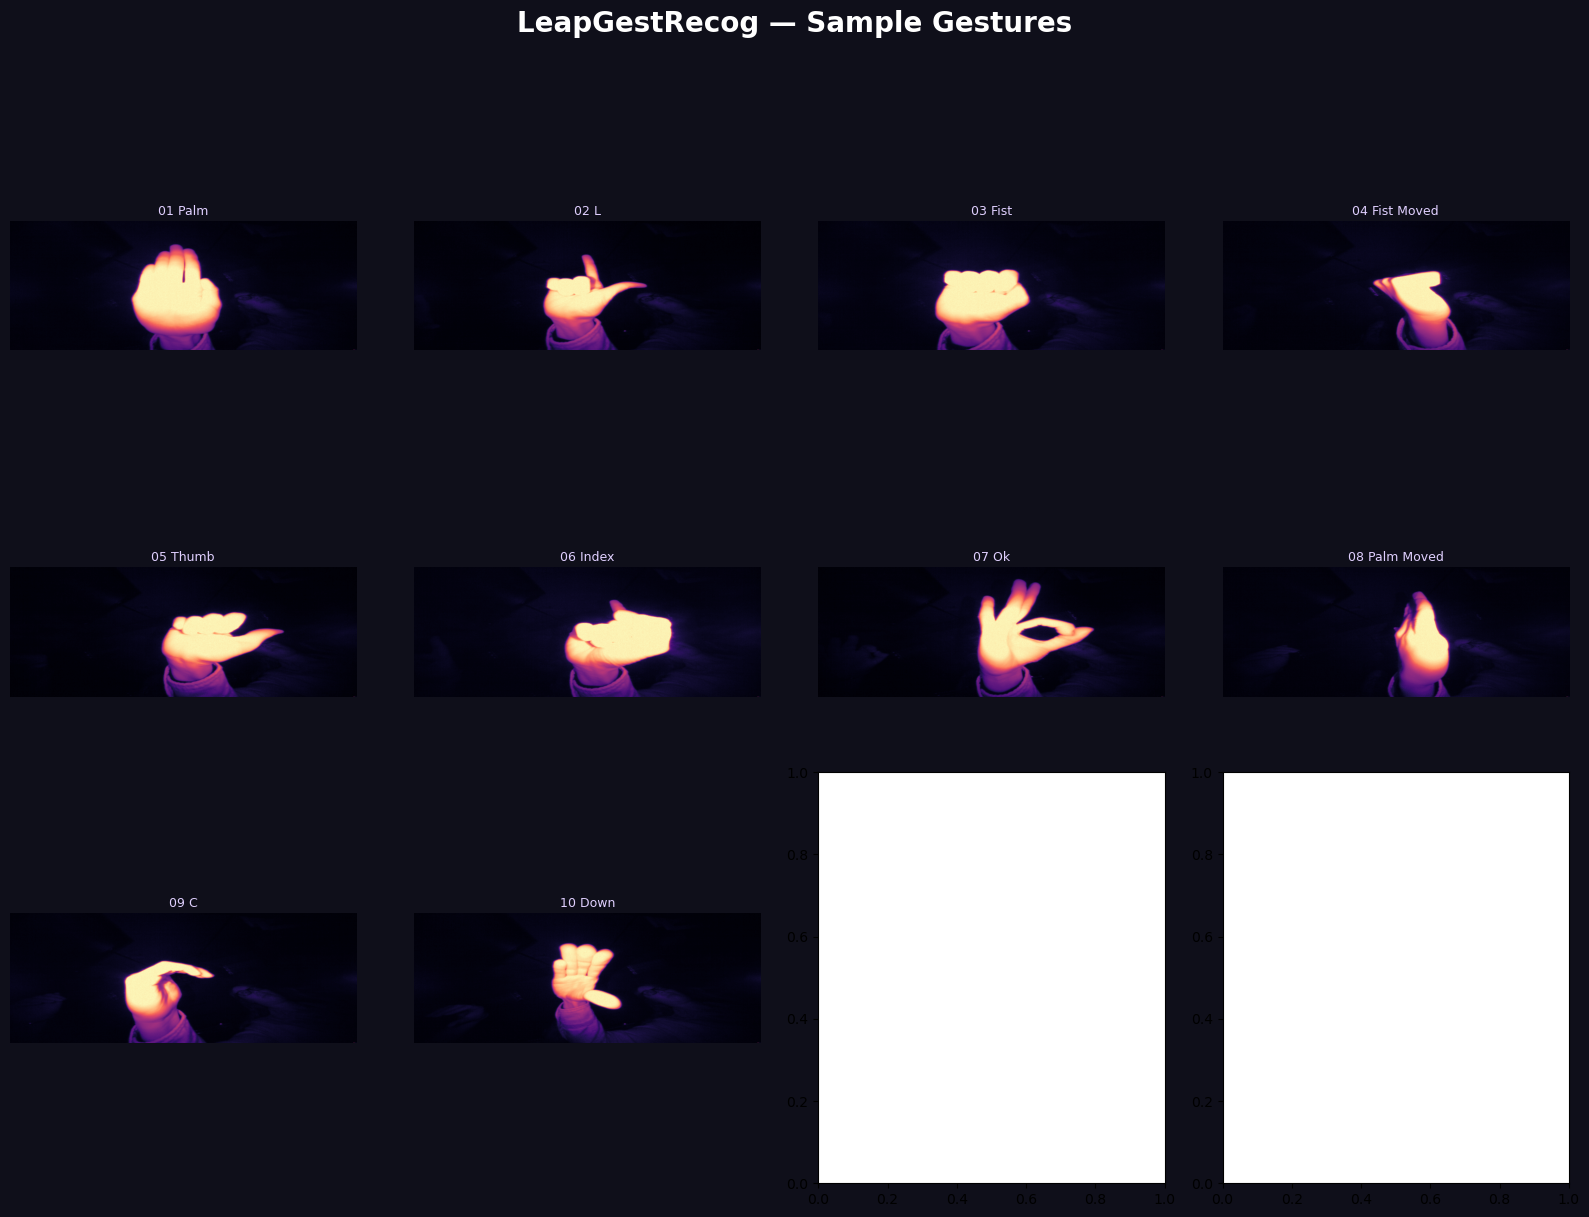

📸 Saved sample_gestures.png


In [3]:
# ── Visual sample grid ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('LeapGestRecog — Sample Gestures', color='white',
             fontsize=20, fontweight='bold', y=1.01)

for ax, cls in zip(axes.ravel(), GESTURE_CLASSES[:12]):
    cls_dir = os.path.join(DATA_DIR, cls)
    img_file = random.choice(os.listdir(cls_dir))
    img = Image.open(os.path.join(cls_dir, img_file)).convert('L')  # grayscale
    ax.imshow(img, cmap='magma')
    label = cls.replace('_', ' ').title()
    ax.set_title(label, color='#e0d0ff', fontsize=9, pad=4)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('#7b5ea7')

plt.tight_layout()
plt.savefig('sample_gestures.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('📸 Saved sample_gestures.png')

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

# ── Hyperparameters ────────────────────────────────────────────────────────────
IMG_HEIGHT   = 128
IMG_WIDTH    = 128
BATCH_SIZE   = 32
EPOCHS_CNN   = 20
EPOCHS_TL    = 30
SEED         = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Image data generators ──────────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

COLOR_MODE = 'grayscale'   # dataset is IR / grayscale

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

CLASS_NAMES = list(train_gen.class_indices.keys())
NUM_CLASSES  = len(CLASS_NAMES)
print(f"\n✅ Train batches: {len(train_gen)} | Val batches: {len(val_gen)}")
print(f"🏷️  Classes ({NUM_CLASSES}):", CLASS_NAMES)

TensorFlow version: 2.21.0
GPU available: False
Found 1600 images belonging to 10 classes.
Found 400 images belonging to 10 classes.

✅ Train batches: 50 | Val batches: 13
🏷️  Classes (10): ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [5]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)

def build_custom_cnn(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.4)(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Head
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name='HandGesture_CNN')


INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 1)  # grayscale
cnn_model = build_custom_cnn(INPUT_SHAPE, NUM_CLASSES)
cnn_model.summary()

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_cnn = [
    EarlyStopping(patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_cnn_model.h5', save_best_only=True, verbose=1)
]

print("\n🚀 Training Custom CNN...")
history_cnn = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_CNN,
    callbacks=callbacks_cnn,
    verbose=1
)

Model: "HandGesture_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 851,946 (3.25 MB)

 Trainable params: 849,514 (3.24 MB)

 Non-trainable params: 2,432 (9.50 KB)


🚀 Training Custom CNN...
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3492 - loss: 2.0853 - top3_acc: 0.6516  
Epoch 1: val_loss improved from None to 3.87260, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.5213 - loss: 1.4895 - top3_acc: 0.8125 - val_accuracy: 0.1000 - val_loss: 3.8726 - val_top3_acc: 0.3000 - learning_rate: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8173 - loss: 0.5830 - top3_acc: 0.9844  
Epoch 2: val_loss did not improve from 3.87260
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8419 - loss: 0.4983 - top3_acc: 0.9850 - val_accuracy: 0.1000 - val_loss: 6.9199 - val_top3_acc: 0.3000 - learning_rate: 0.0010
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9120 - loss: 0.3133 - top3_acc: 0.9963 
Epoch 3: val_loss did not improve from 3.87260
50/50 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9369 - loss: 0.2315 - top3_acc: 0.9987 - val_accuracy: 0.1000 - val_loss: 10.3474 - val_top3_acc: 0.3000 - learning_rate: 0.0010
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9621 - loss: 0.1584 - top3_acc: 1.0000

In [11]:
# MobileNetV2 expects 3-channel RGB input → use RGB mode generators
train_gen_rgb = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
).flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen_rgb = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
).flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

# ── Build MobileNetV2 model ────────────────────────────────────────────────────
def build_mobilenetv2(input_shape, num_classes):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False   # freeze base initially

    inputs  = tf.keras.Input(shape=input_shape)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name='HandGesture_MobileNetV2'), base


tl_model, base_model = build_mobilenetv2((IMG_HEIGHT, IMG_WIDTH, 3), NUM_CLASSES)
tl_model.summary()

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_tl = [
    EarlyStopping(patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_tl_model.h5', save_best_only=True, verbose=1)
]

# Phase 1: Train head only
print("\n🔵 Phase 1 — Training classification head...")
history_tl_1 = tl_model.fit(
    train_gen_rgb, validation_data=val_gen_rgb,
    epochs=15, callbacks=callbacks_tl, verbose=1
)

# Phase 2: Fine-tune top layers of base
print("\n🟣 Phase 2 — Fine-tuning top 50 layers of MobileNetV2...")
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),   # low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

history_tl_2 = tl_model.fit(
    train_gen_rgb, validation_data=val_gen_rgb,
    epochs=EPOCHS_TL, callbacks=callbacks_tl, verbose=1
)

Found 1600 images belonging to 10 classes.
Found 400 images belonging to 10 classes.


Model: "HandGesture_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ multiply_1 (Multiply)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_1 (TrueDivide)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_1 (Subtract)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,047,754 (11.63 MB)

 Trainable params: 789,770 (3.01 MB)

...


🔵 Phase 1 — Training classification head...
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.6000 - loss: 1.3210 - top3_acc: 0.7838 
Epoch 1: val_loss improved from None to 0.15764, saving model to best_tl_model.h5



Epoch 1: finished saving model to best_tl_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 344ms/step - accuracy: 0.8019 - loss: 0.6752 - top3_acc: 0.9194 - val_accuracy: 0.9775 - val_loss: 0.1576 - val_top3_acc: 0.9975 - learning_rate: 0.0010
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9710 - loss: 0.1407 - top3_acc: 0.9997 
Epoch 2: val_loss did not improve from 0.15764
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 317ms/step - accuracy: 0.9775 - loss: 0.1306 - top3_acc: 0.9987 - val_accuracy: 0.9725 - val_loss: 0.1591 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.9901 - loss: 0.0957 - top3_acc: 1.0000 
Epoch 3: val_loss improved from 0.15764 to 0.10545, saving model to best_tl_model.h5



Epoch 3: finished saving model to best_tl_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 395ms/step - accuracy: 0.9862 - loss: 0.1038 - top3_acc: 1.0000 - val_accuracy: 0.9750 - val_loss: 0.1055 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9817 - loss: 0.0986 - top3_acc: 1.0000 
Epoch 4: val_loss did not improve from 0.10545
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 385ms/step - accuracy: 0.9844 - loss: 0.0978 - top3_acc: 1.0000 - val_accuracy: 0.9875 - val_loss: 0.1313 - val_top3_acc: 0.9900 - learning_rate: 0.0010
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9845 - loss: 0.1050 - top3_acc: 1.0000 
Epoch 5: val_loss did not improve from 0.10545
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 354ms/step - accuracy: 0.9894 - loss: 0.0914 - top3_acc: 1.0000 - val_accuracy: 0.9850 - val_loss: 0.1210 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9898 - loss: 0.0783 - to


Epoch 1: finished saving model to best_tl_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 462ms/step - accuracy: 0.8087 - loss: 0.6545 - top3_acc: 0.9519 - val_accuracy: 0.9775 - val_loss: 0.0999 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9109 - loss: 0.3302 - top3_acc: 0.9876 
Epoch 2: val_loss did not improve from 0.09988
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 445ms/step - accuracy: 0.9287 - loss: 0.2773 - top3_acc: 0.9906 - val_accuracy: 0.9800 - val_loss: 0.1002 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9488 - loss: 0.2158 - top3_acc: 0.9938 
Epoch 3: val_loss did not improve from 0.09988
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 455ms/step - accuracy: 0.9625 - loss: 0.1901 - top3_acc: 0.9950 - val_accuracy: 0.9800 - val_loss: 0.1000 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9843 - loss:


Epoch 4: finished saving model to best_tl_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 456ms/step - accuracy: 0.9837 - loss: 0.1283 - top3_acc: 1.0000 - val_accuracy: 0.9800 - val_loss: 0.0998 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9879 - loss: 0.1279 - top3_acc: 0.9979 
Epoch 5: val_loss did not improve from 0.09977
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 362ms/step - accuracy: 0.9894 - loss: 0.1153 - top3_acc: 0.9987 - val_accuracy: 0.9800 - val_loss: 0.1029 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9899 - loss: 0.1015 - top3_acc: 1.0000 
Epoch 6: val_loss did not improve from 0.09977
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 467ms/step - accuracy: 0.9912 - loss: 0.1038 - top3_acc: 1.0000 - val_accuracy: 0.9825 - val_loss: 0.1077 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9927 - loss:

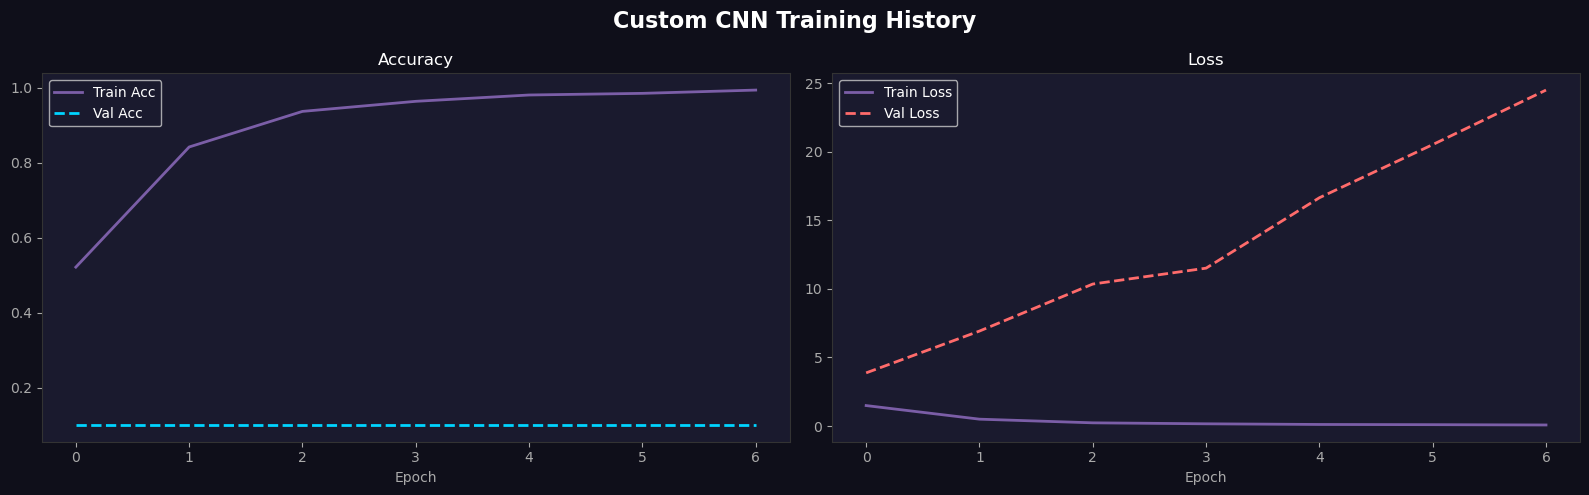

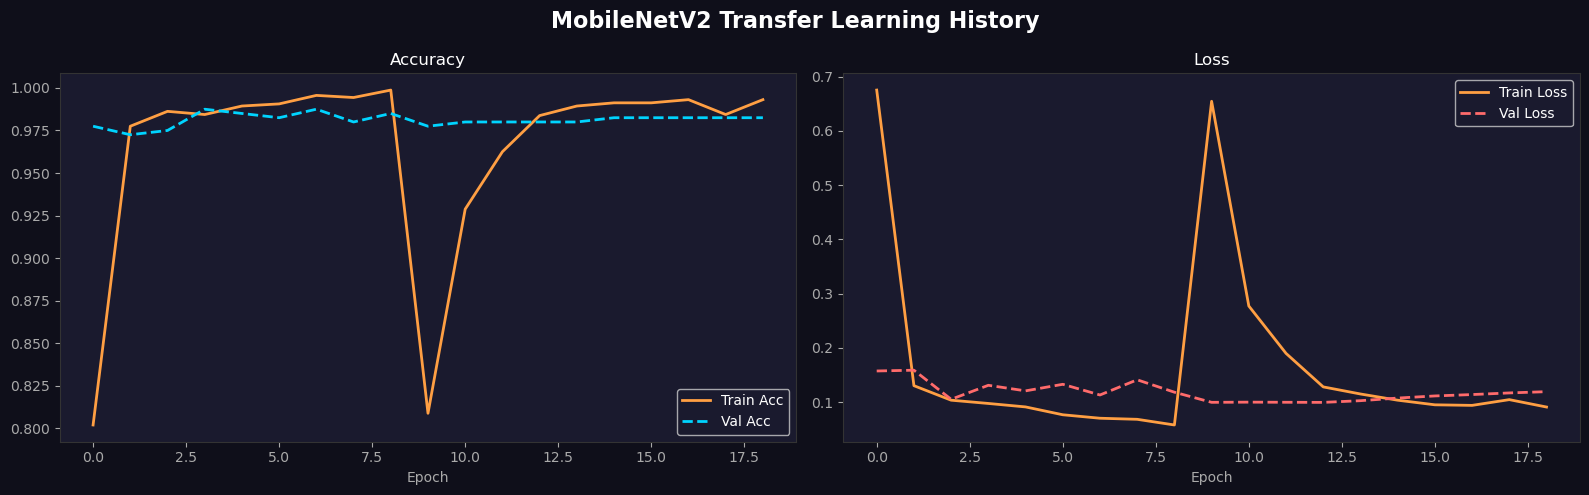

'mobilenetv2_transfer_learning_history.png'

In [12]:
def plot_history(hist, title, color='#7b5ea7'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle(title, color='white', fontsize=16, fontweight='bold')

    for ax in axes:
        ax.set_facecolor('#1a1a2e')
        ax.tick_params(colors='#aaa')
        ax.spines[:].set_color('#333')

    # Accuracy
    axes[0].plot(hist['accuracy'], color=color, lw=2, label='Train Acc')
    axes[0].plot(hist['val_accuracy'], color='#00d4ff', lw=2, linestyle='--',
                 label='Val Acc')
    axes[0].set_title('Accuracy', color='white')
    axes[0].set_xlabel('Epoch', color='#aaa')
    axes[0].legend(facecolor='#1a1a2e', labelcolor='white')
    axes[0].yaxis.label.set_color('#aaa')

    # Loss
    axes[1].plot(hist['loss'], color=color, lw=2, label='Train Loss')
    axes[1].plot(hist['val_loss'], color='#ff6b6b', lw=2, linestyle='--',
                 label='Val Loss')
    axes[1].set_title('Loss', color='white')
    axes[1].set_xlabel('Epoch', color='#aaa')
    axes[1].legend(facecolor='#1a1a2e', labelcolor='white')

    plt.tight_layout()
    fname = title.replace(' ', '_').lower() + '.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    return fname

plot_history(history_cnn.history, 'Custom CNN Training History')

# Merge TL phase histories
merged = {k: history_tl_1.history[k] + history_tl_2.history[k]
          for k in history_tl_1.history}
plot_history(merged, 'MobileNetV2 Transfer Learning History', color='#ff9f43')


📈 Evaluating Custom CNN...
✅ Custom CNN — Overall Accuracy: 10.00%

               precision    recall  f1-score   support

      01_palm       0.00      0.00      0.00        40
         02_l       0.00      0.00      0.00        40
      03_fist       0.00      0.00      0.00        40
04_fist_moved       0.00      0.00      0.00        40
     05_thumb       0.00      0.00      0.00        40
     06_index       0.10      1.00      0.18        40
        07_ok       0.00      0.00      0.00        40
08_palm_moved       0.00      0.00      0.00        40
         09_c       0.00      0.00      0.00        40
      10_down       0.00      0.00      0.00        40

     accuracy                           0.10       400
    macro avg       0.01      0.10      0.02       400
 weighted avg       0.01      0.10      0.02       400



C:\Users\shahf\Contacts\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\shahf\Contacts\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\shahf\Contacts\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


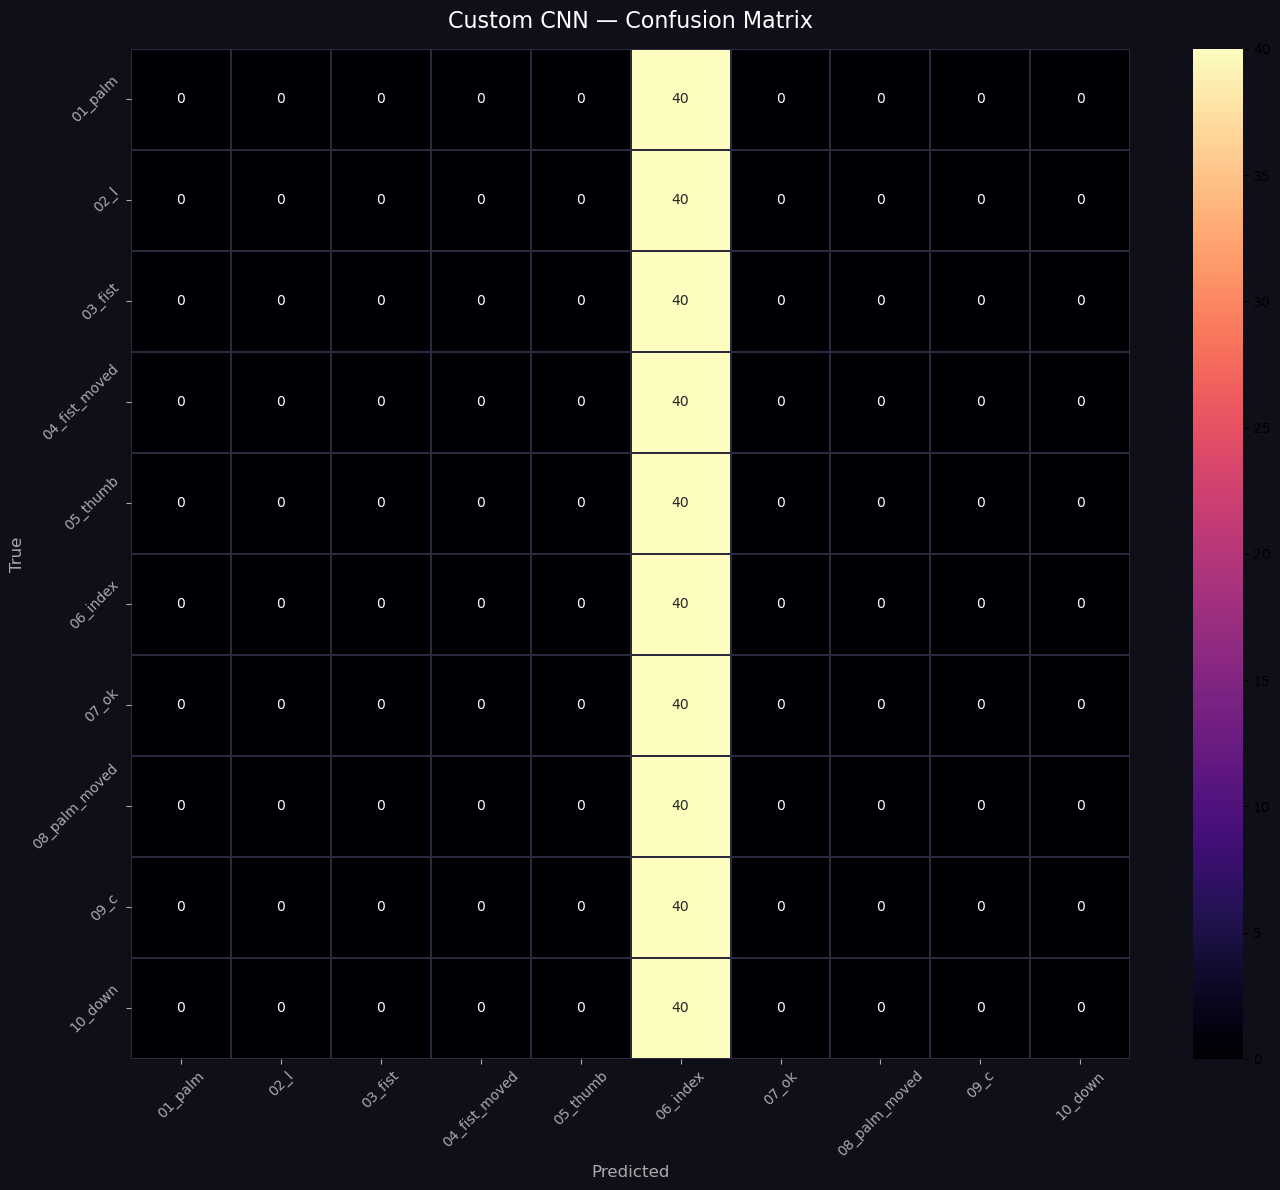


📈 Evaluating MobileNetV2 Transfer Learning...
✅ MobileNetV2 Transfer Learning — Overall Accuracy: 98.75%

               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00        40
         02_l       1.00      1.00      1.00        40
      03_fist       0.98      1.00      0.99        40
04_fist_moved       0.93      1.00      0.96        40
     05_thumb       1.00      0.97      0.99        40
     06_index       1.00      1.00      1.00        40
        07_ok       1.00      1.00      1.00        40
08_palm_moved       0.98      1.00      0.99        40
         09_c       1.00      0.90      0.95        40
      10_down       1.00      1.00      1.00        40

     accuracy                           0.99       400
    macro avg       0.99      0.99      0.99       400
 weighted avg       0.99      0.99      0.99       400



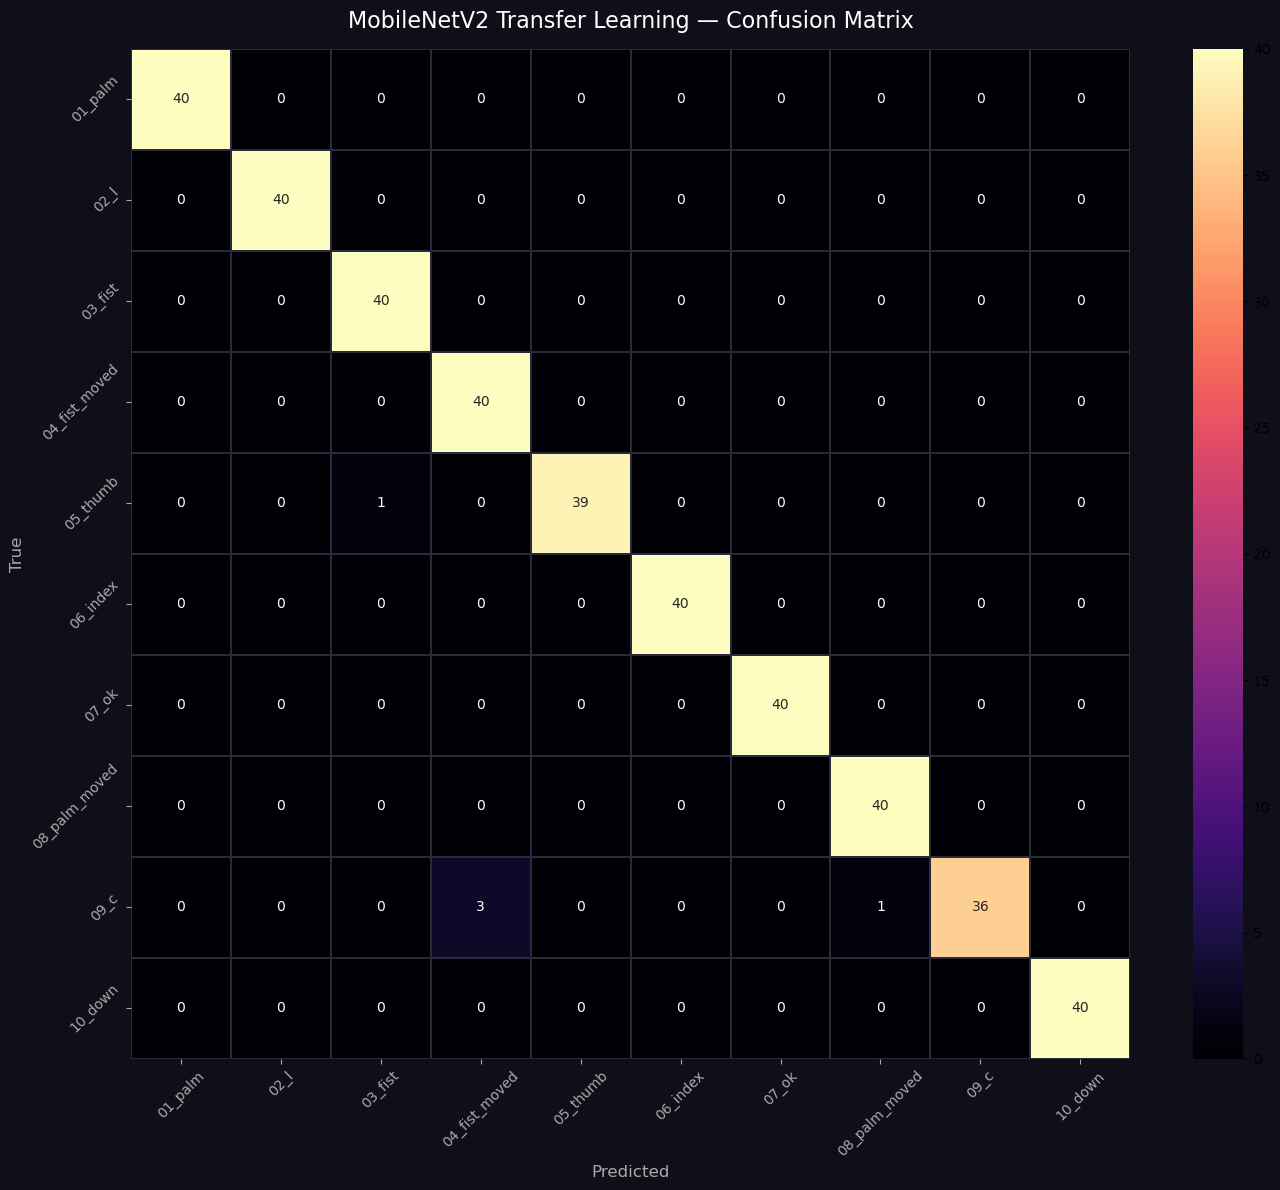


  Custom CNN Accuracy      : 10.00%
  MobileNetV2 TL Accuracy  : 98.75%


In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, generator, model_name='Model', color_mode='rgb'):
    print(f"\n📈 Evaluating {model_name}...")
    generator.reset()

    y_true, y_pred_prob = [], []
    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        preds = model.predict(X_batch, verbose=0)
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred_prob.extend(preds)

    y_true      = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred      = np.argmax(y_pred_prob, axis=1)

    acc = np.mean(y_true == y_pred)
    print(f"✅ {model_name} — Overall Accuracy: {acc*100:.2f}%")
    print("\n" + classification_report(y_true, y_pred,
                                       target_names=CLASS_NAMES))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(14, 12))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.3, linecolor='#2a2a3e', ax=ax)
    ax.set_title(f'{model_name} — Confusion Matrix', color='white',
                 fontsize=16, pad=15)
    ax.set_xlabel('Predicted', color='#aaa', fontsize=12)
    ax.set_ylabel('True', color='#aaa', fontsize=12)
    ax.tick_params(colors='#aaa', rotation=45)

    plt.tight_layout()
    fname = model_name.replace(' ', '_').lower() + '_confusion.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    return acc, y_true, y_pred


# Evaluate both models
acc_cnn, yt_cnn, yp_cnn = evaluate_model(
    cnn_model, val_gen, model_name='Custom CNN', color_mode='grayscale')

acc_tl, yt_tl, yp_tl = evaluate_model(
    tl_model, val_gen_rgb, model_name='MobileNetV2 Transfer Learning')

print(f"\n{'='*50}")
print(f"  Custom CNN Accuracy      : {acc_cnn*100:.2f}%")
print(f"  MobileNetV2 TL Accuracy  : {acc_tl*100:.2f}%")
print(f"{'='*50}")

Sub-model : mobilenetv2_1.00_128
Conv layer: Conv_1


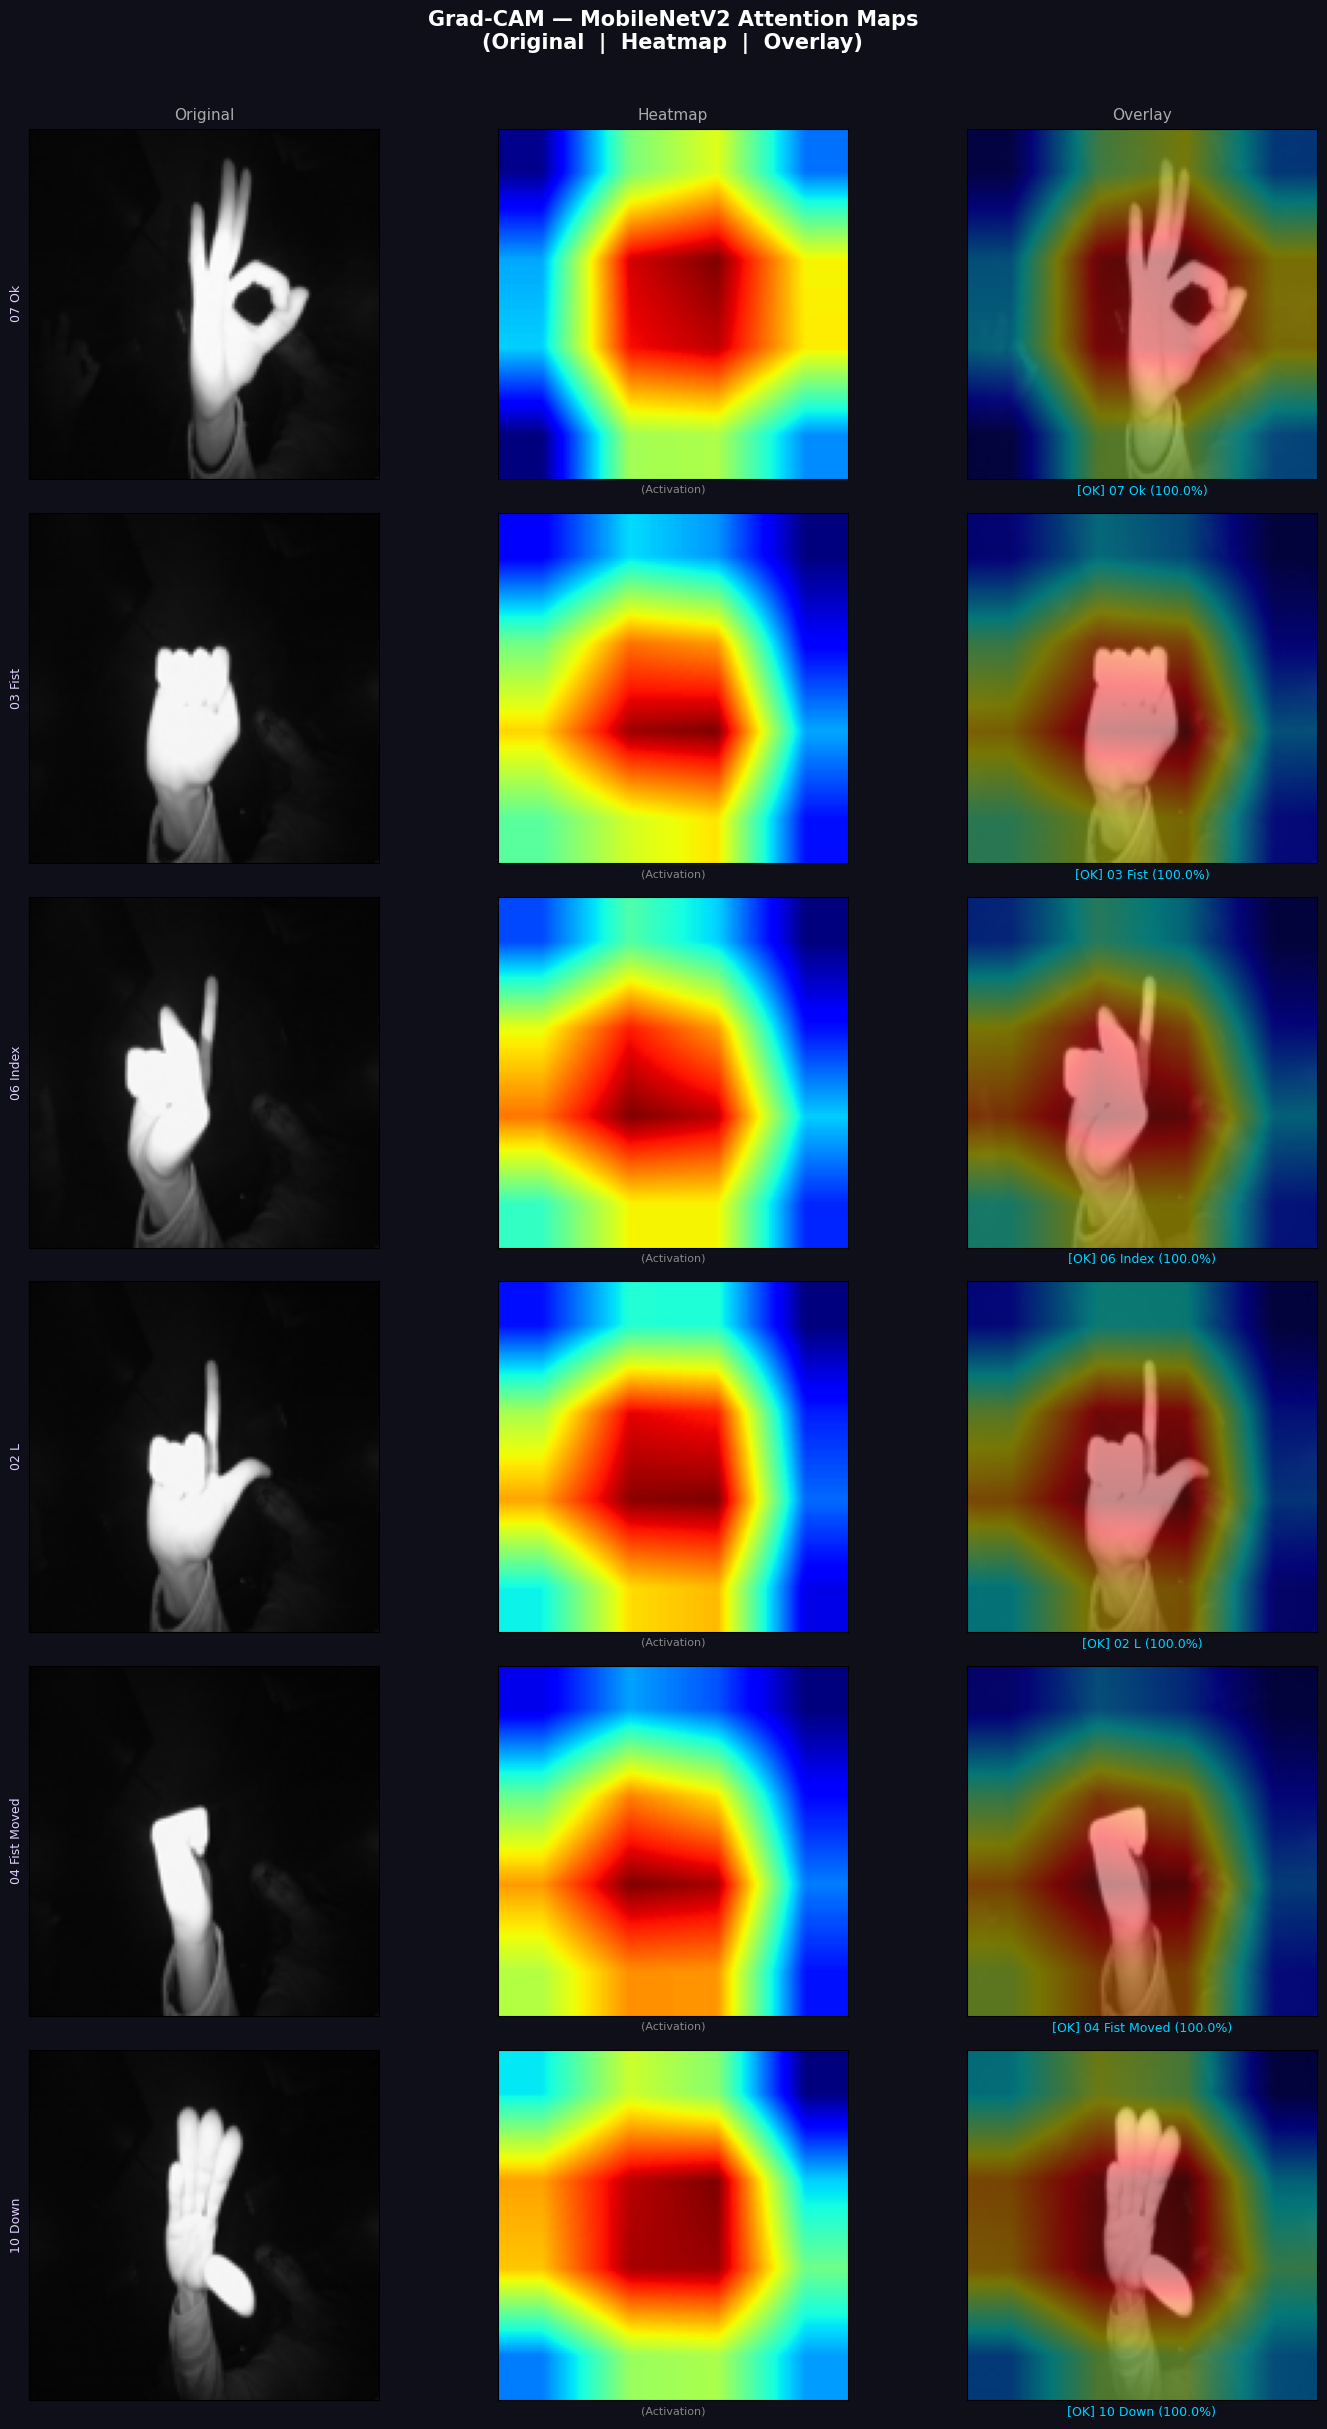

Saved: gradcam_polished.png


In [9]:
# ============================================================
# Step 8 (POLISHED): Grad-CAM with Score-CAM fallback
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import tensorflow as tf
from PIL import Image
import random, os

# ── 1. Rebuild feat_extractor (if not already in memory) ─────
def get_base_submodel(model):
    for layer in model.layers:
        if hasattr(layer, 'layers'):
            return layer
    return None

def find_last_conv_in_model(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

base_submodel  = get_base_submodel(tl_model)
last_conv_name = find_last_conv_in_model(base_submodel)
print(f"Sub-model : {base_submodel.name}")
print(f"Conv layer: {last_conv_name}")

feat_extractor = tf.keras.models.Model(
    inputs  = base_submodel.inputs,
    outputs = [base_submodel.get_layer(last_conv_name).output,
               base_submodel.output],
    name    = 'feat_extractor'
)

head_layers = []
found = False
for layer in tl_model.layers:
    if layer is base_submodel:
        found = True; continue
    if found:
        head_layers.append(layer)

def preprocess(img_f01):
    return img_f01 * 2.0 - 1.0   # [0,1] → [-1,1]

def run_head(base_out):
    h = base_out
    for layer in head_layers:
        h = layer(h, training=False)
    return h


# ── 2. Grad-CAM ───────────────────────────────────────────────
def gradcam(img_batch, pred_index):
    x = tf.constant(preprocess(img_batch), dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        conv_out, base_out = feat_extractor(x, training=False)
        preds  = run_head(base_out)
        score  = preds[:, pred_index]

    grads   = tf.cast(tape.gradient(score, conv_out), tf.float32)
    conv_out= tf.cast(conv_out, tf.float32)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam     = tf.reduce_sum(conv_out[0] * weights, axis=-1)
    cam     = tf.nn.relu(cam).numpy()
    return cam, conv_out.numpy()[0]


# ── 3. Mean-activation fallback (for vanishing-gradient cases)
def mean_activation_cam(img_batch):
    x = tf.constant(preprocess(img_batch), dtype=tf.float32)
    conv_out, _ = feat_extractor(x, training=False)
    cam = tf.reduce_mean(tf.abs(conv_out[0]), axis=-1).numpy()
    return cam


# ── 4. Normalise & decide which CAM to use ───────────────────
MIN_SIGNAL = 0.01   # if max < 1% of range → treat as vanished

def get_best_cam(img_batch, pred_index):
    cam, conv_out = gradcam(img_batch, pred_index)
    method = 'Grad-CAM'

    if cam.max() < MIN_SIGNAL:
        # Gradient vanished → fall back to mean activation
        cam    = mean_activation_cam(img_batch)
        method = 'Activation'

    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, method


# ── 5. Full pipeline per image ────────────────────────────────
def run_full(img_path, target_size=(128, 128)):
    img_pil  = Image.open(img_path).convert('RGB').resize(target_size)
    orig_rgb = np.array(img_pil, dtype=np.uint8)
    img_f32  = orig_rgb.astype(np.float32) / 255.0
    batch    = np.expand_dims(img_f32, 0)

    # Predict
    x     = tf.constant(preprocess(batch), dtype=tf.float32)
    _, bo = feat_extractor(x, training=False)
    probs = run_head(bo).numpy()[0]
    pred_idx   = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100

    # CAM
    cam, method = get_best_cam(batch, pred_idx)

    # Overlay
    h, w          = orig_rgb.shape[:2]
    cam_resized   = cv2.resize(cam, (w, h))
    cam_uint8     = np.uint8(255 * cam_resized)
    colormap      = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET)
    colormap      = cv2.cvtColor(colormap, cv2.COLOR_BGR2RGB)
    blended       = cv2.addWeighted(orig_rgb, 0.55, colormap, 0.45, 0)

    return orig_rgb, cam_resized, blended, pred_label, confidence, method


# ── 6. Plot ───────────────────────────────────────────────────
NUM_SAMPLES    = min(6, NUM_CLASSES)
sample_classes = random.sample(CLASS_NAMES, NUM_SAMPLES)

fig, axes = plt.subplots(NUM_SAMPLES, 3, figsize=(15, NUM_SAMPLES * 4))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle(
    'Grad-CAM — MobileNetV2 Attention Maps\n'
    '(Original  |  Heatmap  |  Overlay)',
    color='white', fontsize=15, fontweight='bold', y=1.01
)

COL_TITLES = ['Original', 'Heatmap', 'Overlay']

for row, cls in enumerate(sample_classes):
    cls_dir   = os.path.join(DATA_DIR, cls)
    img_files = [f for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.png','.jpg','.jpeg'))]
    img_path  = os.path.join(cls_dir, random.choice(img_files))

    try:
        orig, cam_2d, blended, pred_label, conf, method = run_full(img_path)
    except Exception as e:
        print(f"  SKIP {cls}: {e}"); continue

    correct    = (pred_label == cls)
    pred_color = '#00d4ff' if correct else '#ff6b6b'
    # Plain ASCII — no emoji → no font-missing warnings
    status     = '[OK]' if correct else '[X]'

    for col, (img_data, cmap) in enumerate(
            zip([orig, cam_2d, blended], [None, 'jet', None])):
        ax = axes[row, col]
        ax.set_facecolor('#0f0f1a')

        kw = dict(vmin=0, vmax=1) if cmap == 'jet' else {}
        ax.imshow(img_data, cmap=cmap, **kw)
        ax.set_xticks([]); ax.set_yticks([])

        if row == 0:
            ax.set_title(COL_TITLES[col], color='#aaaaaa',
                         fontsize=11, pad=6)
        if col == 0:
            ax.set_ylabel(cls.replace('_', ' ').title(),
                          color='#e0d0ff', fontsize=9)
        if col == 1:
            # Label which method was used
            ax.set_xlabel(f'({method})', color='#888888', fontsize=8)
        if col == 2:
            ax.set_xlabel(
                f"{status} {pred_label.replace('_',' ').title()} ({conf:.1f}%)",
                color=pred_color, fontsize=9
            )

plt.tight_layout()
plt.savefig('gradcam_polished.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Saved: gradcam_polished.png')

In [ ]:
# ⚠️ NOTE: Run only if webcam is available in Colab / browser
# predict_from_webcam(tl_model, CLASS_NAMES)

from IPython.display import display, Javascript, Image as IPImage
from base64 import b64decode, b64encode
import io, PIL

# JavaScript snippet to capture a single webcam frame
CAPTURE_JS = """
async function captureFrame() {
  const stream = await navigator.mediaDevices.getUserMedia({video: true});
  const video  = document.createElement('video');
  video.srcObject = stream;
  await new Promise(r => video.onloadedmetadata = r);
  video.play();
  await new Promise(r => setTimeout(r, 500));
  const canvas  = document.createElement('canvas');
  canvas.width  = video.videoWidth;
  canvas.height = video.videoHeight;
  canvas.getContext('2d').drawImage(video, 0, 0);
  stream.getTracks().forEach(t => t.stop());
  return canvas.toDataURL('image/jpeg', 0.9);
}
captureFrame();
"""

def predict_from_webcam(model, class_names, target_size=(128, 128)):
    print("📷 Capturing from webcam...")
    data_url = eval_js(CAPTURE_JS)
    img_bytes = b64decode(data_url.split(',')[1])
    img = PIL.Image.open(io.BytesIO(img_bytes)).convert('RGB')
    img_resized = img.resize(target_size)

    arr = np.array(img_resized) / 255.
    arr = np.expand_dims(arr, 0)

    preds = model.predict(arr, verbose=0)[0]
    top3  = np.argsort(preds)[::-1][:3]

    # Display
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#0f0f1a')

    ax[0].imshow(img_resized)
    ax[0].set_title('Captured Frame', color='white')
    ax[0].axis('off')
    ax[0].set_facecolor('#0f0f1a')

    colors = ['#7b5ea7', '#00d4ff', '#ff9f43']
    labels = [class_names[i].replace('_', ' ').title() for i in top3]
    ax[1].set_facecolor('#1a1a2e')
    bars = ax[1].barh(labels[::-1], [preds[i]*100 for i in top3][::-1],
                      color=colors[::-1], edgecolor='none', height=0.5)
    ax[1].set_title('Top-3 Predictions', color='white')
    ax[1].set_xlabel('Confidence (%)', color='#aaa')
    ax[1].tick_params(colors='#aaa')
    ax[1].spines[:].set_color('#333')
    ax[1].set_xlim(0, 105)
    for bar, conf in zip(bars, [preds[i]*100 for i in top3][::-1]):
        ax[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                   f'{conf:.1f}%', va='center', color='white', fontsize=9)

    plt.tight_layout()
    plt.savefig('webcam_prediction.png', dpi=150, bbox_inches='tight',
                facecolor='#0f0f1a')
    plt.show()
    print(f"\n🏆 Predicted gesture: {class_names[top3[0]].replace('_',' ').title()} "
          f"({preds[top3[0]]*100:.1f}% confidence)")


In [15]:
# ============================================================
# Step 10: Save Models & Export Summary  (Keras 3 compatible)
# ============================================================
import json, datetime

# ── 1. Save models — .keras format (Keras 3 native) ──────────
cnn_model.save('hand_gesture_cnn.keras')
tl_model.save('hand_gesture_mobilenetv2.keras')
print("✅ Models saved in .keras format")

# ── 2. Export to TFLite (quantized) ──────────────────────────
# Keras 3 requires model.export() first, then convert from SavedModel
EXPORT_PATH = 'hand_gesture_mobilenetv2_export'
tl_model.export(EXPORT_PATH)          # writes a proper SavedModel directory

converter = tf.lite.TFLiteConverter.from_saved_model(EXPORT_PATH)
converter.optimizations = [tf.lite.Optimize.DEFAULT]   # int8 quantization

try:
    tflite_model = converter.convert()
    with open('hand_gesture_mobilenetv2.tflite', 'wb') as f:
        f.write(tflite_model)
    tflite_size = len(tflite_model) / 1024
    print(f"✅ TFLite model saved — size: {tflite_size:.1f} KB")
except Exception as e:
    print(f"⚠️  TFLite conversion failed: {e}")
    print("    Models are still saved in .keras format above.")

# ── 3. Save class names ───────────────────────────────────────
with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)
print("✅ class_names.json saved")

# ── 4. Summary report ────────────────────────────────────────
report = {
    'timestamp'         : str(datetime.datetime.now()),
    'keras_version'     : tf.keras.__version__,
    'tensorflow_version': tf.__version__,
    'dataset'           : 'LeapGestRecog (gti-upm)',
    'num_classes'       : NUM_CLASSES,
    'classes'           : CLASS_NAMES,
    'image_size'        : f'{IMG_HEIGHT}x{IMG_WIDTH}',
    'custom_cnn_acc'    : f'{acc_cnn*100:.2f}%',
    'mobilenetv2_acc'   : f'{acc_tl*100:.2f}%',
    'best_model'        : 'MobileNetV2 Transfer Learning',
    'saved_formats'     : {
        'cnn'         : 'hand_gesture_cnn.keras',
        'mobilenetv2' : 'hand_gesture_mobilenetv2.keras',
        'tflite'      : 'hand_gesture_mobilenetv2.tflite'
    },
    'gradcam_saved'     : 'gradcam_results.png'
}

with open('training_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("\n📋 Training Report:")
print(json.dumps(report, indent=2))

# ── 5. Download all outputs to your local machine ────────────
from google.colab import files

for fname in [
    'hand_gesture_cnn.keras',
    'hand_gesture_mobilenetv2.keras',
    'hand_gesture_mobilenetv2.tflite',
    'class_names.json',
    'training_report.json',
    'gradcam_results.png',
    'sample_gestures.png',
]:
    try:
        files.download(fname)
        print(f"⬇️  Downloading: {fname}")
    except Exception:
        print(f"⚠️  Not found (skipping): {fname}")

✅ Models saved in .keras format
INFO:tensorflow:Assets written to: hand_gesture_mobilenetv2_export\assets


INFO:tensorflow:Assets written to: hand_gesture_mobilenetv2_export\assets


Saved artifact at 'hand_gesture_mobilenetv2_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_359')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1479685515472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1479685516048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1479685514512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1479685515856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1479685515280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1479685515088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1479685516816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1479685516624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1479685517008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1479685514320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1479685516240:

ModuleNotFoundError: No module named 'google.colab'